In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Importing the dataset

In [32]:
data = pd.read_csv("hotel_bookings.csv")
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [33]:
data.info

<bound method DataFrame.info of                hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27  

In [34]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

# Basic Data Exploration

In [35]:
data.shape

(119390, 32)

In [36]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

Handle missing values

In [37]:
data["children"] = data["children"].fillna(0)
data["country"] = data["country"].fillna(data["country"].mode()[0])
data["agent"] = data["agent"].fillna(0)

In [38]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               0
babies                                 0
meal                                   0
country                                0
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                                  0
company         

# Exploratory Data Analysis

1) Booking Cancellation Distribution (Target Variable)

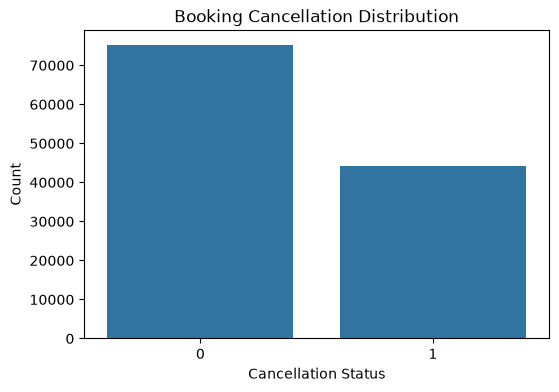

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=data)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Count")
plt.show()

Insight: Shows the proportion of canceled vs. non-canceled bookings.

2) Cancellation by Hotel Type 

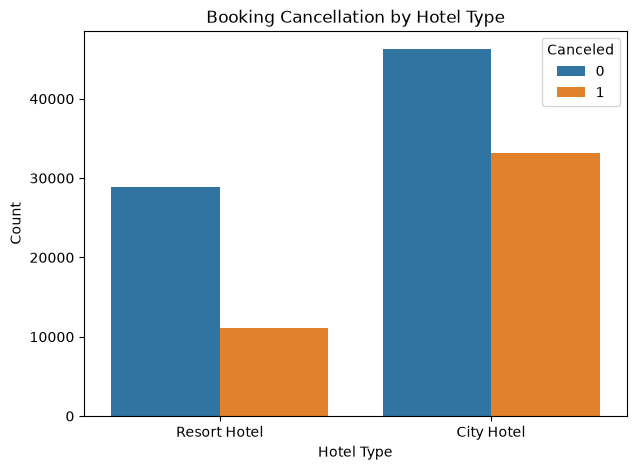

In [40]:
plt.figure(figsize=(7,5))
sns.countplot(x="hotel", hue="is_canceled", data=data)
plt.title("Booking Cancellation by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.legend(title="Canceled")
plt.show()

Insight: Compare cancellation patterns between Resort Hotel and City Hotel.

3) Lead Time vs Cancellation

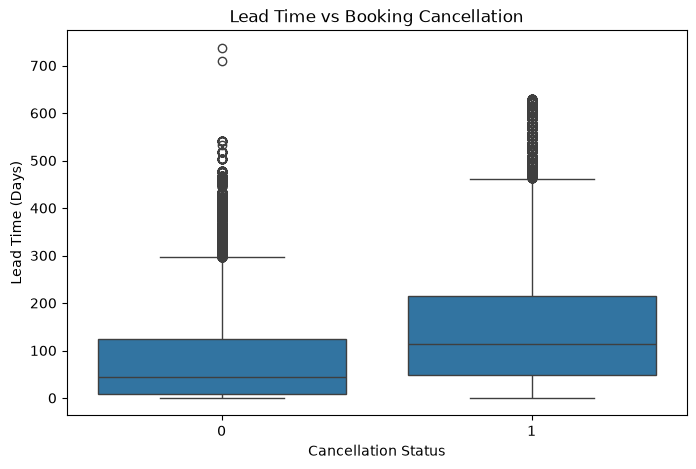

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_canceled", y="lead_time", data=data)
plt.title("Lead Time vs Booking Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")
plt.show()

Insight:-

- Bookings that were canceled (`is_canceled = 1`) generally have a higher lead time than bookings that were not canceled.
- This suggests that reservations made well in advance are more likely to be canceled.
- Lead time appears to be an important feature for predicting booking cancellations.

4) Correlation Heatmap

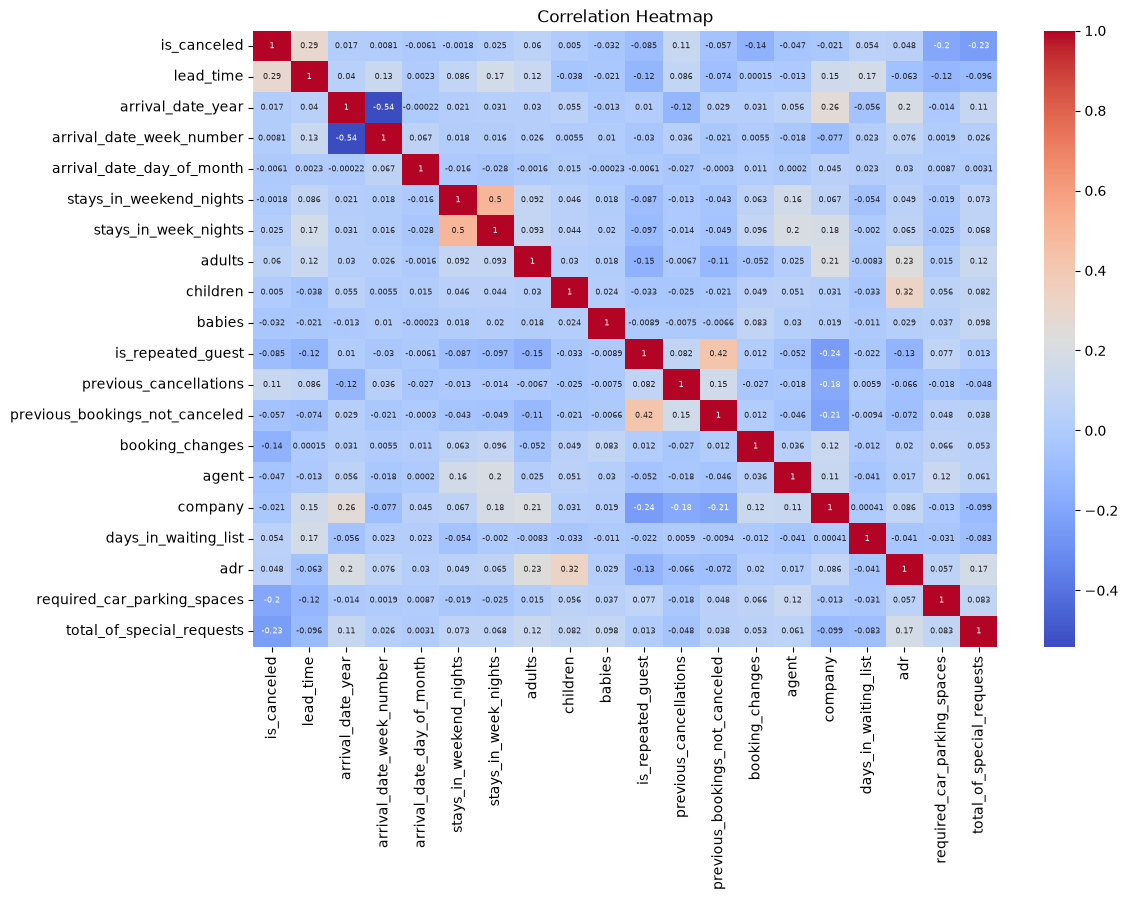

In [42]:
plt.figure(figsize=(12,8))
numeric_data = data.select_dtypes(include=["int64", "float64"])
sns.heatmap(
    numeric_data.corr(),
    cmap="coolwarm",
    annot=True,
    annot_kws={"size":6}
)
plt.title("Correlation Heatmap")
plt.show()

### Observation

- `lead_time` shows the strongest positive correlation with booking cancellation, indicating that bookings made well in advance are more likely to be canceled.
- `total_of_special_requests` and `required_car_parking_spaces` have negative correlations with the target, suggesting that customers with additional requirements are less likely to cancel.
- Most features exhibit weak linear correlations, indicating that multiple variables together contribute to predicting booking cancellations.

# Feature Engineering

In [43]:
data["total_guests"] = (
    data["adults"] +
    data["children"] +
    data["babies"]
)
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0


In [44]:
data.drop(
    columns=[
        "reservation_status",
        "reservation_status_date",
        "company"
    ],
    inplace=True,
    errors="ignore"
)
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0.0,0,Transient,0.0,0,0,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0.0,0,Transient,0.0,0,0,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0.0,0,Transient,75.0,0,0,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,0,Transient,75.0,0,0,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,0,Transient,98.0,0,1,2.0


In [45]:
data.shape

(119390, 30)

In [46]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests'],
      dtype='object')

# Data Preprocessing

In [47]:
X = data.drop("is_canceled", axis=1)
y = data["is_canceled"]

In [48]:
X = pd.get_dummies(X, drop_first=True)

Train test split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature scaling

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (95512, 247)
Testing Features  : (23878, 247)
Training Labels   : (95512,)
Testing Labels    : (23878,)


### Model Building

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

1) Logistic Regression

In [53]:
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print("Accuracy :",acc_lr )
print("Precision:", prec_lr)
print("Recall   :", rec_lr)
print("F1 Score :", f1_lr)

Accuracy : 0.8189965658765391
Precision: 0.8118880154461453
Recall   : 0.6655737704918033
F1 Score : 0.731486083499006


2) Decision Tree

In [54]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt= recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy :", acc_dt)
print("Precision:", prec_dt)
print("Recall   :", rec_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.8588659016668063
Precision: 0.8087289951505583
Recall   : 0.8107405313736574
F1 Score : 0.8097335140018067


3) Random Forest

In [55]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf=  recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", acc_rf )
print("Precision:", prec_rf)
print("Recall   :",rec_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.8939190887008962
Precision: 0.8933200398803589
Recall   : 0.8104013566986998
F1 Score : 0.8498429071077124


Confusion matrix for rf

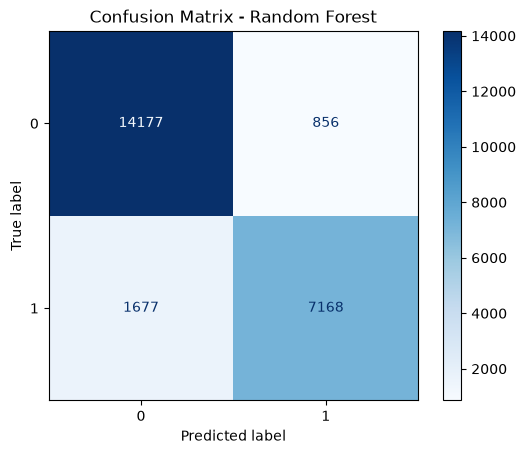

In [56]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Model Evaluation

In [57]:
model_results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [acc_lr, acc_dt, acc_rf],
    "Precision": [prec_lr, prec_dt, prec_rf],
    "Recall": [rec_lr, rec_dt, rec_rf],
    "F1 Score": [f1_lr, f1_dt, f1_rf]
}

results = pd.DataFrame(model_results)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.818997,0.811888,0.665574,0.731486
1,Decision Tree,0.858866,0.808729,0.810741,0.809734
2,Random Forest,0.893919,0.893320,0.810401,0.849843


# Model Performance Comparison

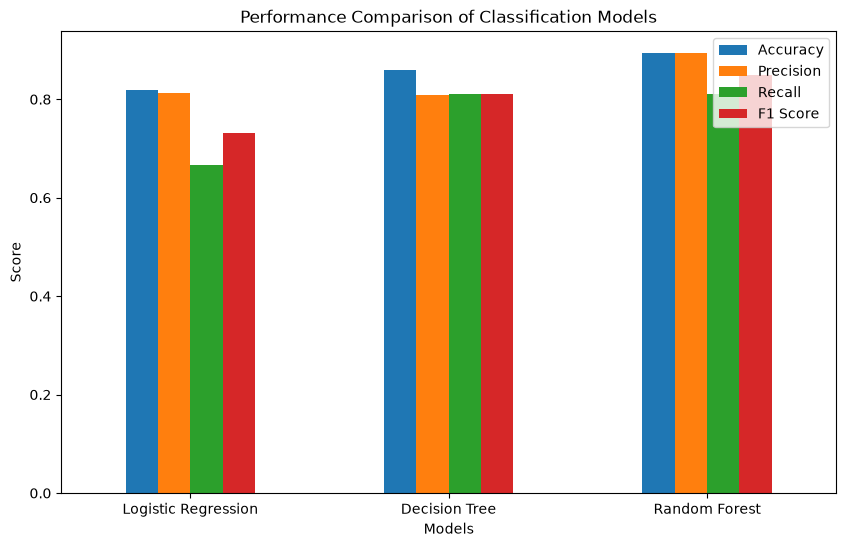

In [58]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Performance Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=0)
plt.legend()
plt.show()

Based on the evaluation metrics, Random Forest is the best-performing model for Hotel Booking Cancellation Prediction. Therefore, it is selected as the final model for predicting booking cancellations.


# Feature Important Analysis

In [59]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,lead_time,0.111555
242,deposit_type_Non Refund,0.080780
15,adr,0.068205
169,country_PRT,0.066278
17,total_of_special_requests,0.058690
3,arrival_date_day_of_month,0.050401
2,arrival_date_week_number,0.045313
13,agent,0.043951
5,stays_in_week_nights,0.035809
10,previous_cancellations,0.032434


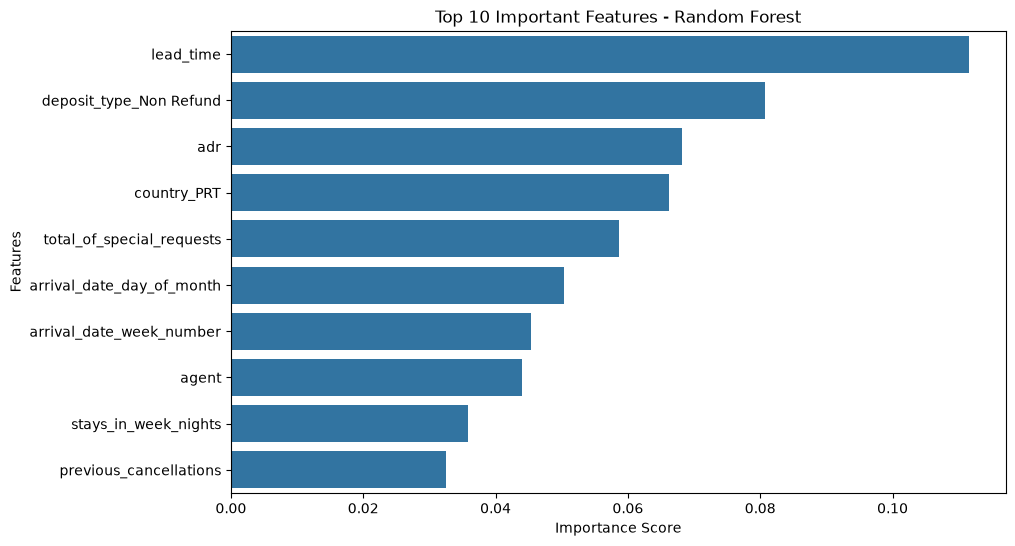

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## Conclusion

* Random Forest achieved the highest performance among all models.
* It obtained the highest accuracy (89.39%) and F1-score (84.98%).
* Decision Tree performed better than Logistic Regression but slightly lower than Random Forest.
* Logistic Regression served as a baseline model.
* Important features identified by Random Forest helped understand factors influencing predictions.